In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost
import catboost
import matplotlib.pyplot as plt

# Data collection

In [2]:
df_raw = pd.read_excel('for_analyses_kama_realistic(chichnew3_3).xlsx')

# удаляем нерелевантные признаки
df = df_raw.copy()
'''df.drop(columns=['reg_date', 'Аl3+','G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle'], 
            inplace=True)'''

df.drop(columns=['reg_date', 'G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle', 'uepp_end', 'SiO2_end',
                 'Аl3+', 'NO', 'Sum_cations', 'Sum_anions', 'turb' ], 
        inplace=True)

pd.set_option('display.float_format', '{:.2f}'.format)

df

,pH,Alkal,hardness,Сl,SO2,Са2,Mg2_max,Na_K_max,Fe_total,total_sal,PO,SiO2
0,8.03,0.72,1.44,8.48,21.75,23.56,3.81,4.63,0.08,170.00,5.16,5.67
1,8.02,0.73,1.55,11.33,29.71,24.19,3.78,6.20,0.10,170.00,4.90,6.32
2,7.96,0.77,1.54,12.29,29.07,24.82,4.24,5.48,0.10,173.85,5.57,5.70
3,7.97,0.71,1.79,13.68,31.43,28.40,5.50,5.51,0.11,174.48,6.06,6.65
4,8.04,0.74,1.64,10.46,30.91,25.41,4.47,6.07,0.08,170.22,5.54,4.96
...,...,...,...,...,...,...,...,...,...,...,...,...
106,7.69,0.81,1.38,17.87,42.42,23.60,3.34,6.09,0.33,172.00,8.55,7.93
107,7.86,0.94,2.75,25.62,50.58,41.57,7.93,7.10,0.29,236.15,8.05,8.17
108,7.89,0.76,1.71,12.33,36.93,24.74,4.82,5.92,0.27,175.87,6.20,7.53
109,7.83,0.68,1.88,17.08,39.07,28.90,5.47,5.22,0.27,180.43,7.90,7.43


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pH         111 non-null    float64
 1   Alkal      111 non-null    float64
 2   hardness   111 non-null    float64
 3   Сl         111 non-null    float64
 4   SO2        111 non-null    float64
 5   Са2        111 non-null    float64
 6   Mg2_max    111 non-null    float64
 7   Na_K_max   111 non-null    float64
 8   Fe_total   111 non-null    float64
 9   total_sal  111 non-null    float64
 10  PO         111 non-null    float64
 11  SiO2       111 non-null    float64
dtypes: float64(12)
memory usage: 10.5 KB


# Correlation matrix of initial features

In [4]:
df_F_cycle = df.copy()

# целевой признак
df_F_cycle['F_cycle'] = df_raw.F_cycle

df_corr = df_F_cycle.corr('pearson')
df_corr.sort_values(by='F_cycle', axis='columns', ascending=False, inplace=True, key=lambda col: abs(col))
oneline=False
(df_corr, df_corr.iloc[-1])[bool(oneline)]


,F_cycle,Са2,hardness,Mg2_max,Сl,SO2,total_sal,Alkal,Na_K_max,SiO2,PO,pH,Fe_total
pH,-0.03,0.07,0.09,-0.01,-0.26,-0.23,-0.16,-0.04,-0.04,-0.37,-0.52,1.00,-0.68
Alkal,-0.54,0.70,0.68,0.58,0.76,0.67,0.67,1.00,0.51,0.44,0.39,-0.04,0.09
hardness,-0.71,0.96,1.00,0.86,0.66,0.63,0.78,0.68,0.55,0.31,0.28,0.09,-0.13
Сl,-0.59,0.69,0.66,0.69,1.00,0.90,0.76,0.76,0.47,0.66,0.68,-0.26,0.35
SO2,-0.56,0.64,0.63,0.65,0.90,1.00,0.70,0.67,0.46,0.62,0.66,-0.23,0.32
Са2,-0.73,1.00,0.96,0.79,0.69,0.64,0.77,0.70,0.57,0.33,0.31,0.07,-0.12
Mg2_max,-0.63,0.79,0.86,1.00,0.69,0.65,0.74,0.58,0.51,0.37,0.35,-0.01,-0.04
Na_K_max,-0.42,0.57,0.55,0.51,0.47,0.46,0.58,0.51,1.00,0.22,0.23,-0.04,-0.03
Fe_total,0.01,-0.12,-0.13,-0.04,0.35,0.32,0.18,0.09,-0.03,0.47,0.64,-0.68,1.00
total_sal,-0.55,0.77,0.78,0.74,0.76,0.70,1.00,0.67,0.58,0.44,0.49,-0.16,0.18


In [5]:
def corr_matrix(df, target, method):

    df_corr = df.corr(method)
    df_corr.sort_values(by=target, axis='columns', ascending=False, inplace=True, key=lambda col: abs(col))

    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 14

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(df_corr, dtype=bool))

    # Set up the matplotlib figure
    fig, ax = plt.subplots(figsize=(11, 10))
    
    dict_method = {'pearson': 'Пирсона', 'kendall': 'Кенделла', 'spearman': 'Спирмана'}
    
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(df_corr, 
                annot=True, 
                mask=mask, 
                cmap=sns.color_palette("vlag", as_cmap=True),
                fmt=".2f", 
                vmax=1.0, 
                vmin=-1.0, 
                center=0,
                square=True, 
                linewidths=1, 
                cbar_kws={"shrink": .8}).set(title=f'Корреляционная матрица {dict_method[method]} для исходных признаков')

    plt.tight_layout()
    plt.savefig(f'pictures/full_corr_matrix_{target}_{method}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

In [6]:
df_F_cycle = df.copy()

# целевой признак
df_F_cycle['F_cycle'] = df_raw.F_cycle  # `add
#df_F_cycle.drop(columns=['признак'], inplace=True)  # remove

df_F_cycle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pH         111 non-null    float64
 1   Alkal      111 non-null    float64
 2   hardness   111 non-null    float64
 3   Сl         111 non-null    float64
 4   SO2        111 non-null    float64
 5   Са2        111 non-null    float64
 6   Mg2_max    111 non-null    float64
 7   Na_K_max   111 non-null    float64
 8   Fe_total   111 non-null    float64
 9   total_sal  111 non-null    float64
 10  PO         111 non-null    float64
 11  SiO2       111 non-null    float64
 12  F_cycle    111 non-null    int64  
dtypes: float64(12), int64(1)
memory usage: 11.4 KB


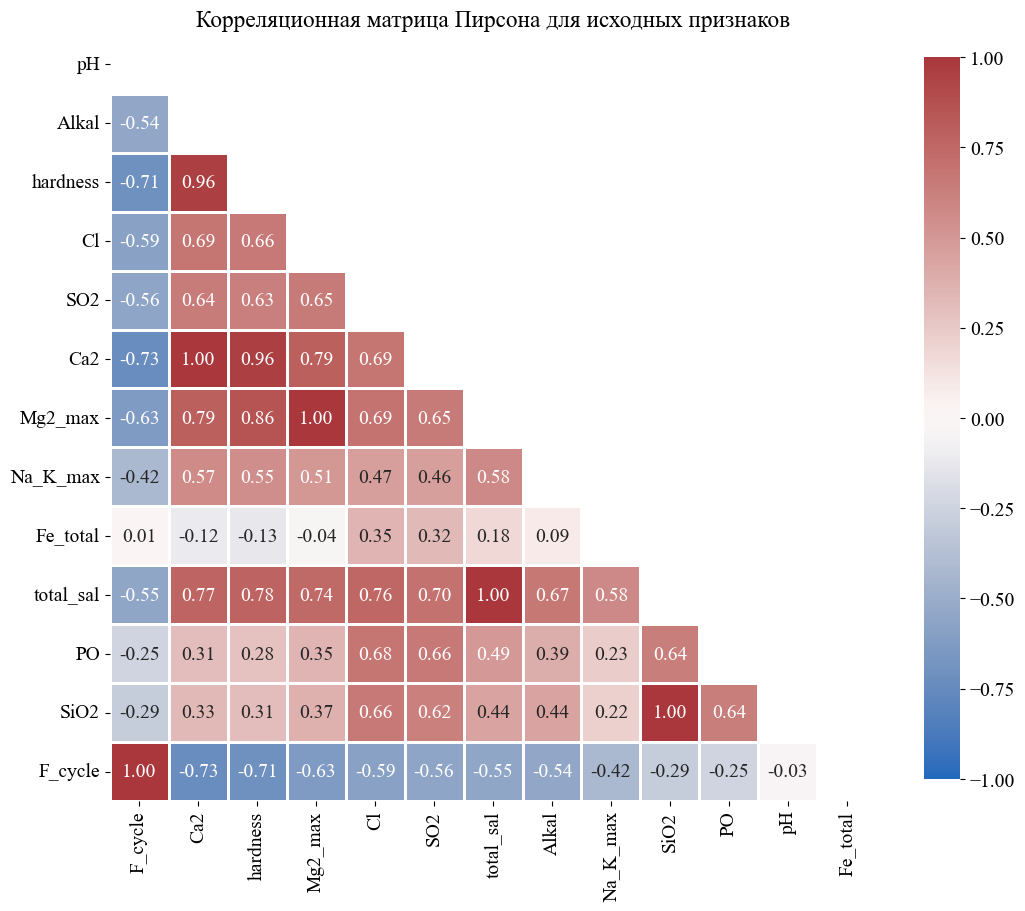

In [7]:
corr_matrix(df=df_F_cycle, target='F_cycle', method='pearson')

## Acid

In [8]:
df_Acid = df.copy()

# целевой признак
df_Acid['SpecG_acid'] = df_raw['SpecG_acid(eq)']
df_Acid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          111 non-null    float64
 1   Alkal       111 non-null    float64
 2   hardness    111 non-null    float64
 3   Сl          111 non-null    float64
 4   SO2         111 non-null    float64
 5   Са2         111 non-null    float64
 6   Mg2_max     111 non-null    float64
 7   Na_K_max    111 non-null    float64
 8   Fe_total    111 non-null    float64
 9   total_sal   111 non-null    float64
 10  PO          111 non-null    float64
 11  SiO2        111 non-null    float64
 12  SpecG_acid  111 non-null    float64
dtypes: float64(13)
memory usage: 11.4 KB


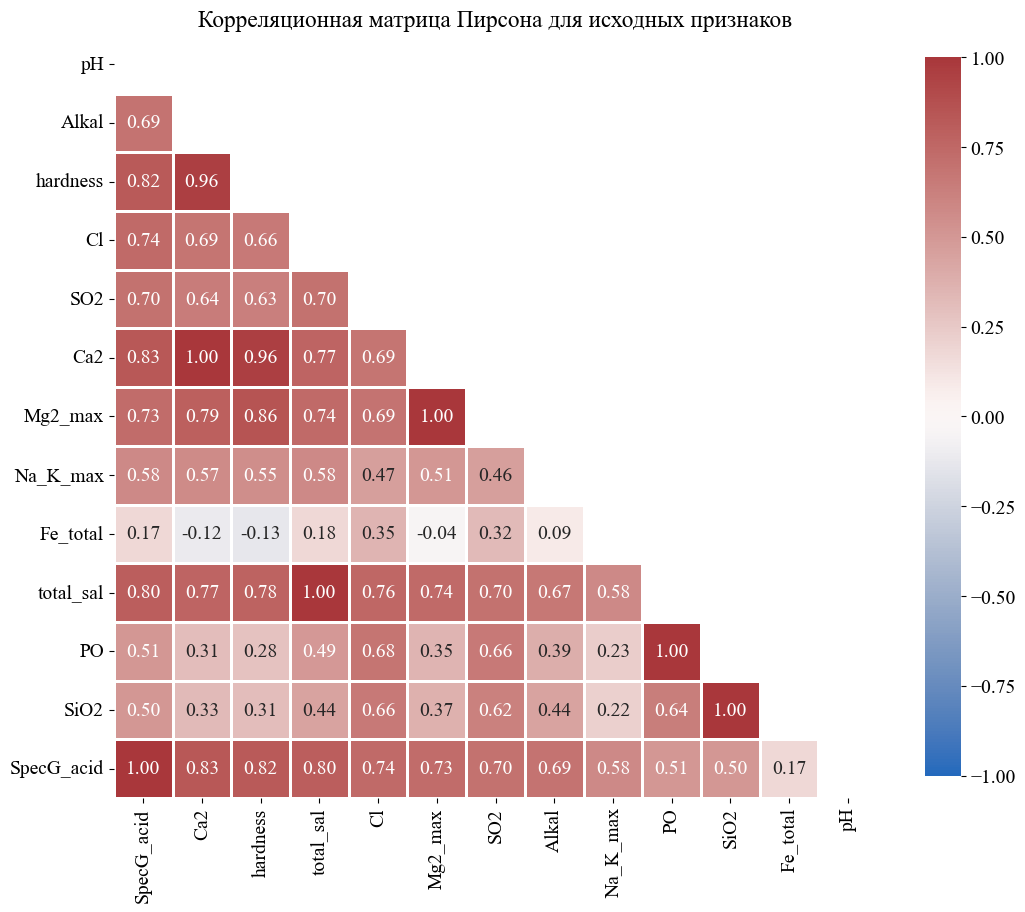

In [9]:
corr_matrix(df=df_Acid, target='SpecG_acid', method='pearson')

## Alcaline

In [10]:
df_Alcaline = df.copy()

# целевой признак
df_Alcaline['SpecG_alkali'] = df_raw['SpecG_alkali(eq)']
df_Alcaline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pH            111 non-null    float64
 1   Alkal         111 non-null    float64
 2   hardness      111 non-null    float64
 3   Сl            111 non-null    float64
 4   SO2           111 non-null    float64
 5   Са2           111 non-null    float64
 6   Mg2_max       111 non-null    float64
 7   Na_K_max      111 non-null    float64
 8   Fe_total      111 non-null    float64
 9   total_sal     111 non-null    float64
 10  PO            111 non-null    float64
 11  SiO2          111 non-null    float64
 12  SpecG_alkali  111 non-null    float64
dtypes: float64(13)
memory usage: 11.4 KB


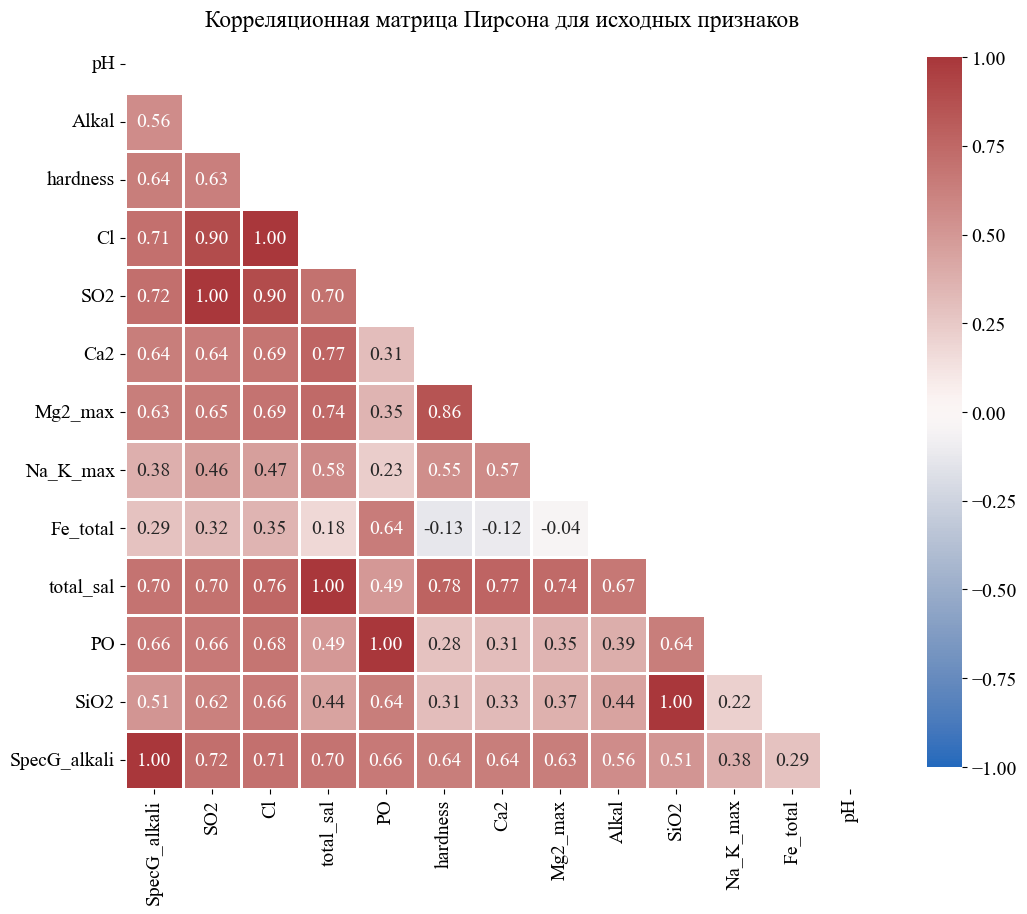

In [11]:
corr_matrix(df=df_Alcaline, target='SpecG_alkali', method='pearson')

# Feature important

In [12]:
def feature_importance_selector(X, y, engine='catboost'):
    
    if engine=='catboost':
        selector = catboost.CatBoostRegressor(silent=True)
    elif engine=='xgboost':
        selector = xgboost.XGBRegressor()
    
    selector.fit(X, y)

    feature_importances = pd.DataFrame({'importance' : selector.feature_importances_}, 
                                       index=X.columns).sort_values(by='importance', ascending=False)

    if engine=='catboost':
        feature_importances.importance /= 100
    
    plt.rcParams['font.size'] = 16
    plt.figure(figsize=(12, 5))
    
    for bar in plt.bar(range(len(feature_importances.index)), feature_importances.importance, align='center', width=0.8):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom')
    
    
    plt.xticks(range(len(feature_importances.index)), feature_importances.index, rotation=90)
    plt.ylim(0, (((feature_importances.importance.max()*100 // 5) + 2) * 5) / 100)

    plt.ylabel('Feature weight')
    plt.title(f'Features importance for {y.name}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'pictures/standard_feature_important_{y.name}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

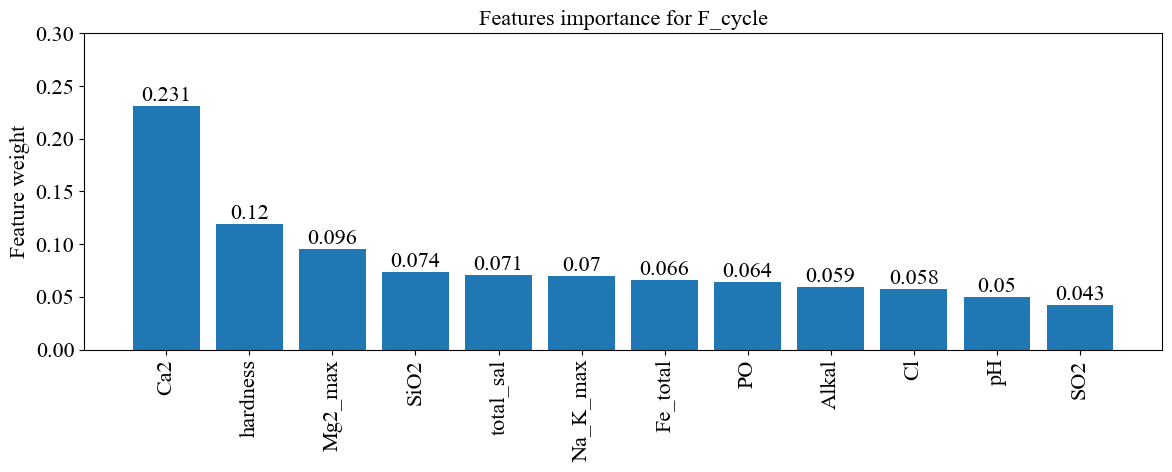

In [13]:
feature_importance_selector(X=df_F_cycle.drop(columns='F_cycle'), 
                            y=df_F_cycle.F_cycle, 
                            engine='catboost')

## Acid

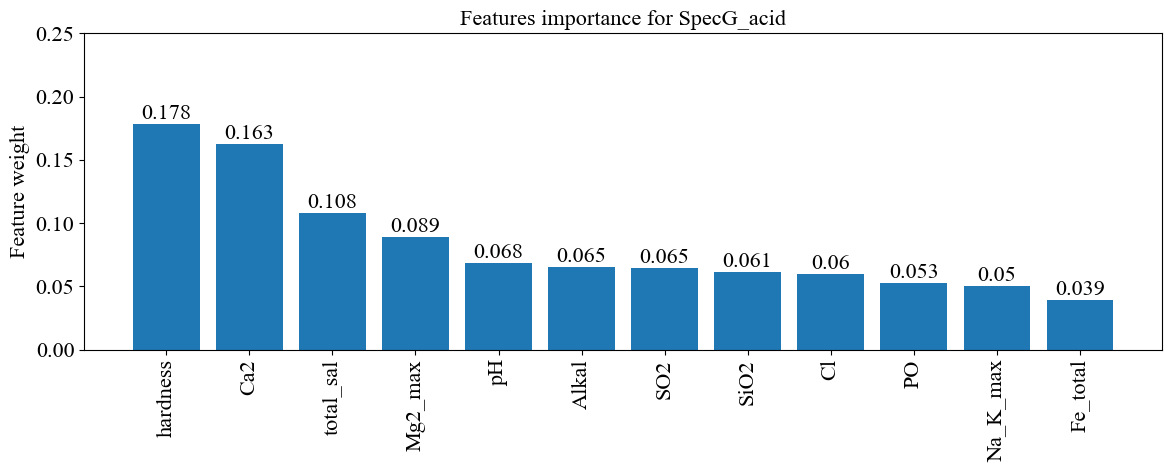

In [14]:
feature_importance_selector(X=df_Acid.drop(columns=['SpecG_acid']), 
                            y=df_Acid.SpecG_acid, 
                            engine='catboost')

## Alcaline

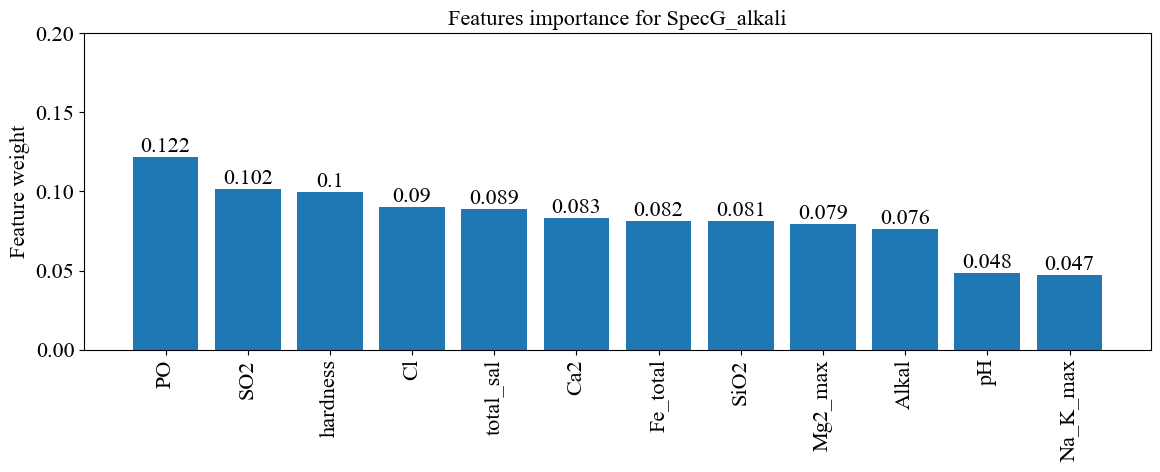

In [15]:
feature_importance_selector(X=df_Alcaline.drop(columns=['SpecG_alkali']), 
                            y=df_Alcaline.SpecG_alkali,
                            engine='catboost')

# Pairplot

In [16]:
def pairplot(df, savefigname):
    plt.figure(figsize=(500,500))
    sns.pairplot(df)
    #plt.tight_layout()
    plt.savefig(f'pictures/pairlpot_{savefigname}.png', dpi = 300, transparent = True)
    plt.show()

## F_cycle

<Figure size 50000x50000 with 0 Axes>

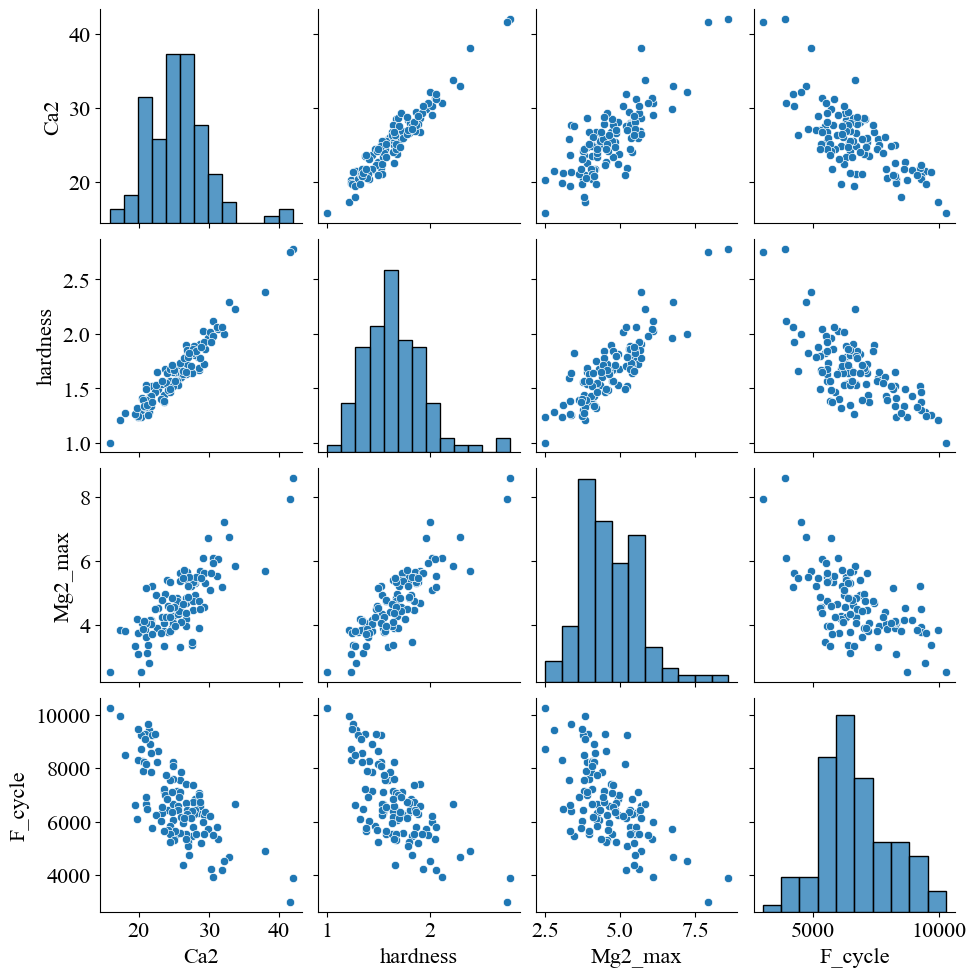

In [17]:
pairplot(df=df_F_cycle[['Са2', 'hardness', 'Mg2_max', 'F_cycle']], savefigname='F_cycle')

## Acid

<Figure size 50000x50000 with 0 Axes>

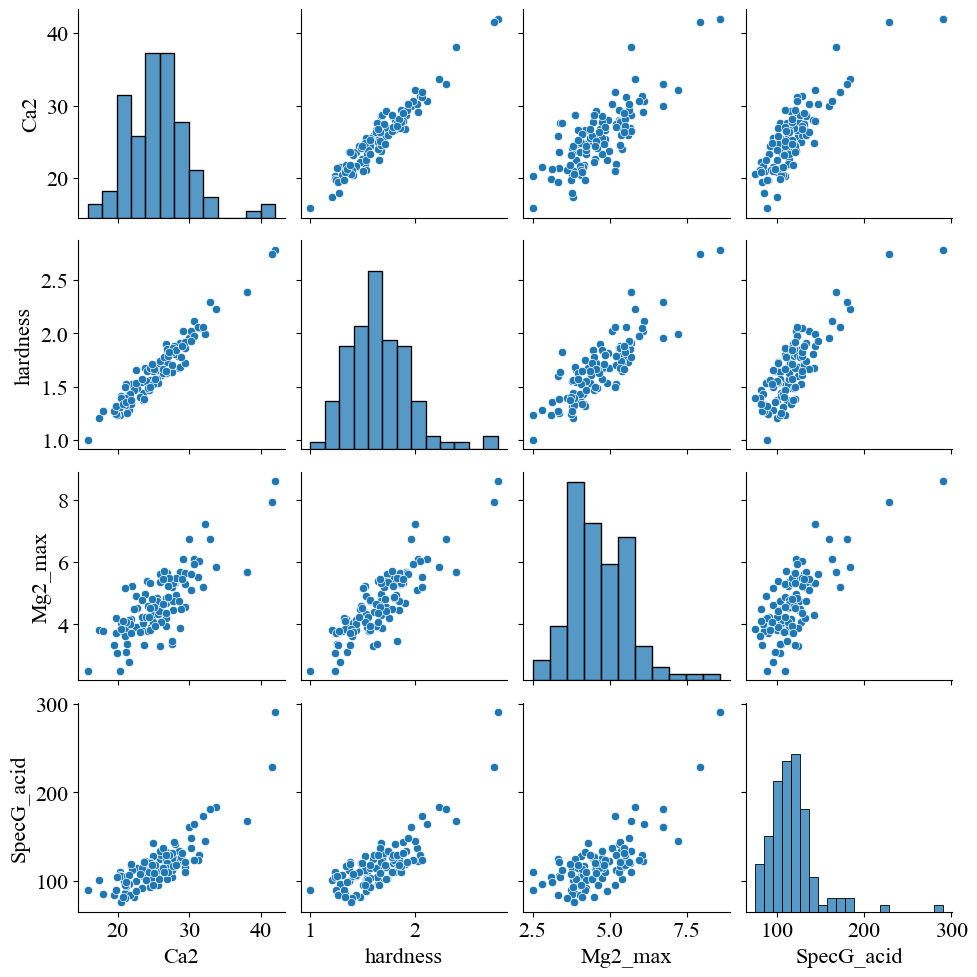

In [18]:
pairplot(df=df_Acid[['Са2', 'hardness', 'Mg2_max', 'SpecG_acid']], savefigname='Acid')

## Alcaline

<Figure size 50000x50000 with 0 Axes>

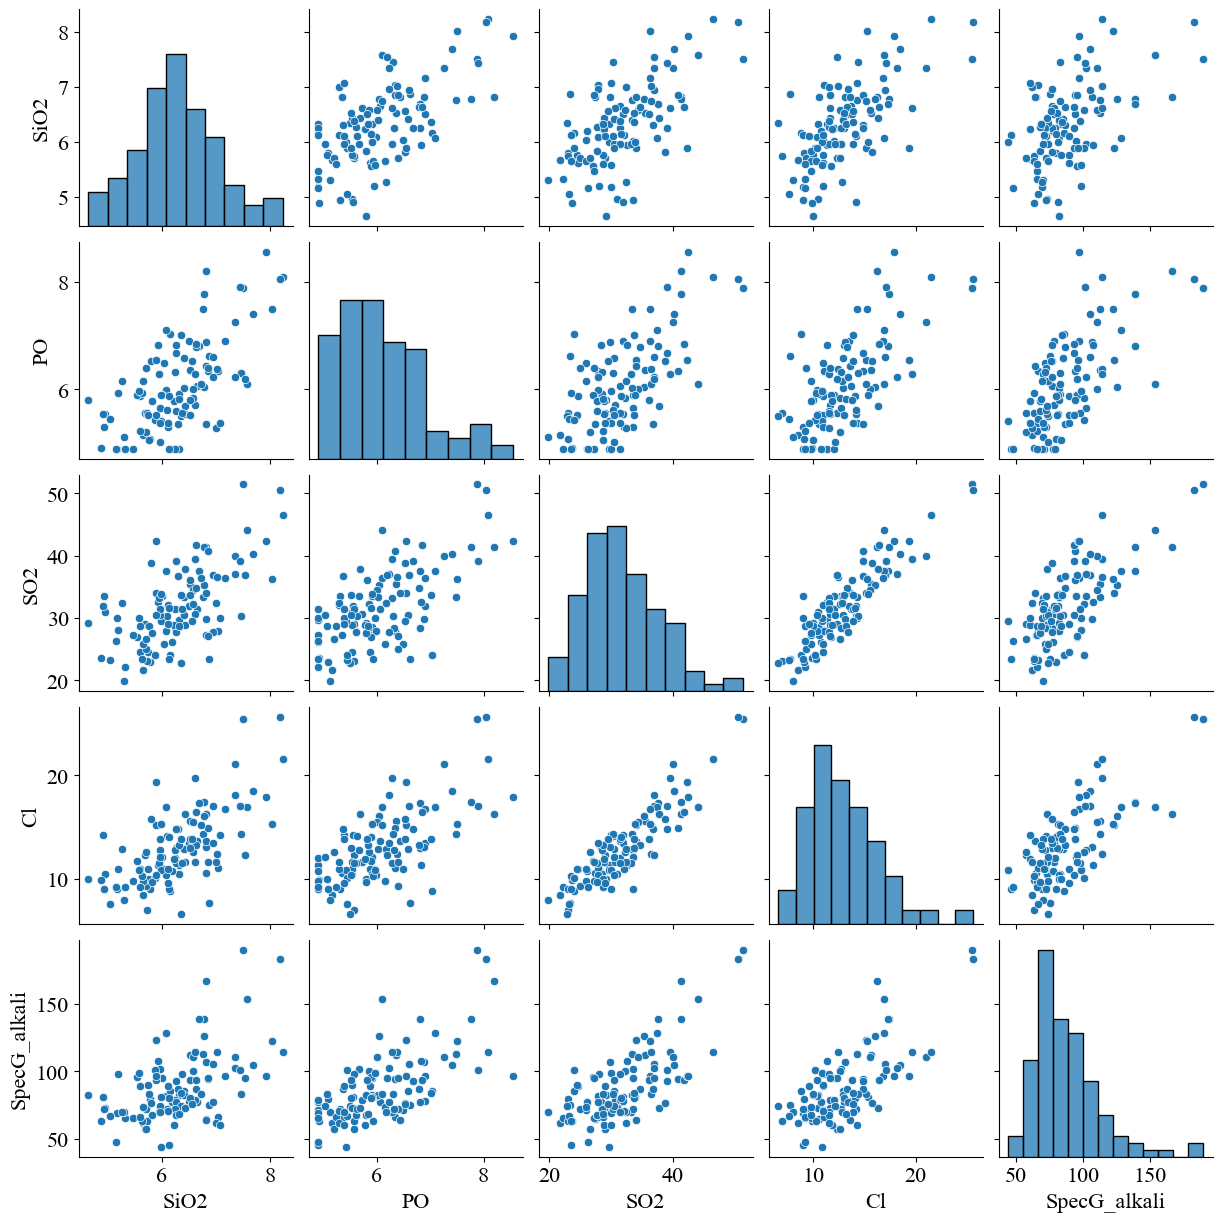

In [19]:
pairplot(df=df_Alcaline[['SiO2', 'PO', 'SO2', 'Сl', 'SpecG_alkali']], savefigname='Alkaline')

# Predictive model

In [20]:
##Catboost

from catboost import CatBoostRegressor 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


df_raw = pd.read_excel('for_analyses_kama_realistic(chichnew3_3).xlsx')

# удаляем нерелевантные признаки
df = df_raw.copy()
'''df.drop(columns=['reg_date', 'Аl3+','G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle'], 
            inplace=True)'''

df.drop(columns=['reg_date', 'G_acid', 'G_alkali', 'SpecG_acid(eq)', 'SpecG_alkali(eq)', 
                 'SpecG_acid', 'SpecG_alkali', 'Acid_alkali_ratio', 'F_cycle', 'uepp_end', 'SiO2_end',
                 'Аl3+', 'NO', 'Sum_cations', 'Sum_anions', 'turb' ], 
        inplace=True)

df


# === Функция обучения модели === 
def train_model_7030(X, y, model_name='target'):

    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

    # Создание модели
    model = CatBoostRegressor( iterations=2500, 
                              depth=7, 
                              learning_rate=0.03, 
                              l2_leaf_reg=10, 
                              loss_function='RMSE', 
                              random_seed=42, 
                              verbose=False )

    # Обучение
    model.fit(X_train, y_train)

    # Предсказания
    y_pred = model.predict(X_test)


    # Метрики
    r2 = r2_score(y_test, y_pred) 
    mae = mean_absolute_error(y_test, y_pred) 
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f'=== Результаты для {model_name} ===') 
    print(f'R2: {r2:.3f}') 
    print(f'MAE: {mae:.3f}') 
    print(f'RMSE: {rmse:.3f}')

    return model

# === 1. Модель для фильтроцикла ===
features_F = ['Са2', 'hardness', 'Mg2_max',
              'total_sal', 'Na_K_max',
              'Alkal', 'SO2', 'Сl'] 
target_F = df_raw['F_cycle']

model_F = train_model_7030(df[features_F], target_F, 'F_cycle')


# === 2. Модель для расхода кислоты ===
features_acid = ['Са2', 'hardness', 'Mg2_max',
                'total_sal', 'Na_K_max', 'Alkal'] 
target_acid = df_raw['SpecG_acid(eq)']

model_acid = train_model_7030(df[features_acid], target_acid, 'SpecG_acid')


# === 3. Модель для расхода щелочи ===
features_alkali = ['PO', 'SO2', 'Сl',
                  'total_sal', 'Alkal','SiO2', 'Na_K_max' ] 
target_alkali = df_raw['SpecG_alkali(eq)']

model_alkali = train_model_7030(df[features_alkali], target_alkali, 'SpecG_alkali')




=== Результаты для F_cycle ===
R2: 0.307
MAE: 791.265
RMSE: 1041.381
=== Результаты для SpecG_acid ===
R2: 0.708
MAE: 11.118
RMSE: 12.782
=== Результаты для SpecG_alkali ===
R2: 0.441
MAE: 16.861
RMSE: 20.982


In [21]:
# === Пример прогноза ===
example = pd.DataFrame({ 'Са2': [20.25], 'hardness': [1.24], 'Mg2_max': [2.5], 'total_sal': [170], 'Na_K_max': [5.03], 'Alkal': [0.62],'SO2': [23], 'Сl': [7] })

prediction = model_F.predict(example)
print("\nПример прогноза F_cycle:")
print(prediction)


Пример прогноза F_cycle:
[8859.00424512]


In [22]:
# === Пример прогноза для удельного расхода кислоты ===

example_acid = pd.DataFrame({ 'Са2': [20], 'hardness': [2.0], 'Mg2_max': [5], 'total_sal': [230], 'Na_K_max': [15], 'Alkal': [3.0] })

prediction_acid = model_acid.predict(example_acid) 
print("\nПример прогноза SpecG_acid:")
print(prediction_acid)


Пример прогноза SpecG_acid:
[135.45413261]


In [23]:
# === Пример прогноза для удельного расхода щелочи ===
example_alkali = pd.DataFrame({ 'PO': [6.5], 'SO2': [30], 'Сl': [15], 'total_sal': [230], 'Alkal': [3.0], 'SiO2': [8.0], 'Na_K_max': [15] })

prediction_alkali = model_alkali.predict(example_alkali) 
print("\nПример прогноза SpecG_alkali:") 
print(prediction_alkali)



Пример прогноза SpecG_alkali:
[110.27298418]
